# ESTUDIO ESTADISTICO

In [13]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu, kruskal, chi2_contingency, rankdata

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


In [14]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================

base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df= pd.read_csv(os.path.join(base_path, "df_classified.csv"))

In [15]:
# ============================================================
# 2. PREPARACION DE DATOS
# ============================================================

# Columnas de clasificación disponibles
clase_cols = {
    "Wiberg": "oleaje_clase_Wiberg",
    "SIMAR": "oleaje_clase_SIMAR",
}

# Verificar cuáles existen
for nombre, col in list(clase_cols.items()):
    if col not in df.columns:
        print(f"⚠️  No se encontró columna '{col}' — se omite escenario {nombre}")
        del clase_cols[nombre]

print("Escenarios disponibles:", list(clase_cols.keys()))
print(f"Total ventanas: {len(df)}")

# Variables de oleaje
vars_oleaje = {
    "Oleaje": "Oleaje",
    "Mod_orbital": "Mod_orbital",
    "STD_orbital": "STD_orbital",
    "Oleaje_SIMAR": "Oleaje_SIMAR",
    "mean_pres": "pres__mean",
    "std_pres": "pres__standard_deviation",
}
# Solo las que existan
vars_oleaje = {k: v for k, v in vars_oleaje.items() if v in df.columns}

ALPHA = 0.05
print(f"Variables de oleaje: {list(vars_oleaje.keys())}")

Escenarios disponibles: ['Wiberg', 'SIMAR']
Total ventanas: 660
Variables de oleaje: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'Oleaje_SIMAR', 'mean_pres', 'std_pres']


## 6.1 Comparación de fuentes de oleaje

Se compara la clasificación generada por cada escenario (Wiberg vs SIMAR) evaluando:
- Correlación inter-fuente (Spearman entre Oleaje Wiberg y Oleaje_SIMAR)
- Concordancia entre clasificaciones (tabla de contingencia)
- Separación del flujo por estado de oleaje (Mann-Whitney U + tamaño del efecto)

In [16]:
# ============================================================
# 6.1a CORRELACIÓN INTER-FUENTE: Oleaje Wiberg vs SIMAR
# ============================================================
import numpy as np

if "Oleaje" in df.columns and "Oleaje_SIMAR" in df.columns:
    aux = df[["Oleaje", "Oleaje_SIMAR"]].dropna()
    rho_inter, p_inter = spearmanr(aux["Oleaje"], aux["Oleaje_SIMAR"])
    print(f"Correlación Spearman entre Oleaje (Wiberg) y Oleaje_SIMAR:")
    print(f"  ρ = {rho_inter:.4f}, p = {p_inter:.2e}, n = {len(aux)}")
else:
    print("No se encontraron ambas columnas de oleaje.")

Correlación Spearman entre Oleaje (Wiberg) y Oleaje_SIMAR:
  ρ = 0.8201, p = 5.68e-135, n = 550


In [17]:
# ============================================================
# 6.1b TABLA COMPARATIVA: evaluación de k para cada escenario
# ============================================================
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Escenarios con features (mismos que notebook 5)
pres_features = ["pres__mean", "pres__standard_deviation", "pres__median"]
escenarios_features = {
    "Wiberg": {"features": ["Oleaje", "Mod_orbital", "STD_orbital"] + pres_features, "col_oleaje": "Oleaje"},
    "SIMAR": {"features": ["Oleaje_SIMAR"] + pres_features, "col_oleaje": "Oleaje_SIMAR"},
}

K_RANGE = range(2, 6)  # Evaluar k=2, 3, 4, 5
resumen_comparacion = []

for nombre, esc in escenarios_features.items():
    features = esc["features"]
    col_oleaje = esc["col_oleaje"]
    X = df[features].copy()
    X_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X))

    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels_raw = km.fit_predict(X_scaled)

        # Reordenar por oleaje ascendente
        df_tmp = df[[col_oleaje]].copy()
        df_tmp["label"] = labels_raw
        orden = df_tmp.groupby("label")[col_oleaje].mean().sort_values().index.tolist()
        mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
        labels = np.array([mapa[l] for l in labels_raw])

        sil = silhouette_score(X_scaled, labels)

        # Test sobre flux_O2
        grupos = df[["flux_O2"]].copy()
        grupos["label"] = labels
        grupos = grupos.dropna(subset=["flux_O2"])
        clases = sorted(grupos["label"].unique())
        muestras = [grupos.loc[grupos["label"] == c, "flux_O2"].values for c in clases]

        if k == 2:
            stat, p = mannwhitneyu(muestras[0], muestras[1], alternative="two-sided")
            n1, n2 = len(muestras[0]), len(muestras[1])
            r_effect = 1 - (2 * stat) / (n1 * n2)
            test_name = "Mann-Whitney"
        else:
            stat, p = kruskal(*muestras)
            r_effect = np.nan  # rank-biserial solo para 2 grupos
            test_name = "Kruskal-Wallis"

        # Diferencia de medianas entre primer y último grupo
        delta_mediana = np.median(muestras[-1]) - np.median(muestras[0])

        resumen_comparacion.append({
            "Escenario": nombre,
            "k": k,
            "Silhouette": round(sil, 4),
            "Test": test_name,
            "Estadístico": round(stat, 2),
            "p-value": round(p, 6),
            "Efecto (r)": round(r_effect, 4) if not np.isnan(r_effect) else "—",
            "Δ mediana (min→max)": round(delta_mediana, 4),
            "Significativo": p < ALPHA,
        })

df_comparacion = pd.DataFrame(resumen_comparacion)
print("="*60)
print("COMPARACIÓN DE ESCENARIOS × NÚMERO DE CLUSTERS")
print("="*60)
display(df_comparacion)

COMPARACIÓN DE ESCENARIOS × NÚMERO DE CLUSTERS


,Escenario,k,Silhouette,Test,Estadístico,p-value,Efecto (r),Δ mediana (min→max),Significativo
0,Wiberg,2,0.3953,Mann-Whitney,62255.00,0.000923,-0.1494,-1.5584,True
1,Wiberg,3,0.3899,Kruskal-Wallis,14.20,0.000824,—,-2.2783,True
2,Wiberg,4,0.3811,Kruskal-Wallis,15.93,0.001171,—,-3.7220,True
3,Wiberg,5,0.3850,Kruskal-Wallis,24.66,0.000059,—,-5.6185,True
4,SIMAR,2,0.3440,Mann-Whitney,49578.00,0.047045,0.0893,1.1483,True
5,SIMAR,3,0.3719,Kruskal-Wallis,15.95,0.000344,—,-2.6145,True
6,SIMAR,4,0.4182,Kruskal-Wallis,20.06,0.000165,—,-3.8852,True
7,SIMAR,5,0.4156,Kruskal-Wallis,33.20,0.000001,—,-1.3866,True


In [18]:
# ============================================================
# 6.1b' RESUMEN: mejor combinación escenario × k
# ============================================================

# Criterio: mayor silhouette entre los significativos
df_sig = df_comparacion[df_comparacion["Significativo"]].copy()

if not df_sig.empty:
    mejor = df_sig.loc[df_sig["Silhouette"].idxmax()]
    print(f"Mejor combinación (mayor silhouette entre los significativos):")
    print(f"  → Escenario: {mejor['Escenario']}, k = {mejor['k']}")
    print(f"    Silhouette = {mejor['Silhouette']}, p = {mejor['p-value']}")
    print(f"    Δ mediana flux = {mejor['Δ mediana (min→max)']}")
else:
    print("Ningún resultado fue significativo.")

print(f"\nRecuerda: el k_final en config.xlsx determina la clasificación del notebook 5.")
print(f"Actualmente las columnas oleaje_clase_Wiberg/SIMAR usan k = {df[list(clase_cols.values())[0]].nunique()}")

Mejor combinación (mayor silhouette entre los significativos):
  → Escenario: SIMAR, k = 4
    Silhouette = 0.4182, p = 0.000165
    Δ mediana flux = -3.8852

Recuerda: el k_final en config.xlsx determina la clasificación del notebook 5.
Actualmente las columnas oleaje_clase_Wiberg/SIMAR usan k = 2


In [19]:
# ============================================================
# 6.1c CONCORDANCIA: tabla de contingencia entre clasificaciones
# ============================================================

if "oleaje_clase_Wiberg" in df.columns and "oleaje_clase_SIMAR" in df.columns:
    tabla = pd.crosstab(
        df["oleaje_clase_Wiberg_nombre"],
        df["oleaje_clase_SIMAR_nombre"],
        rownames=["Wiberg"],
        colnames=["SIMAR"],
    )
    display(tabla)

    concordancia = (df["oleaje_clase_Wiberg"] == df["oleaje_clase_SIMAR"]).mean() * 100
    print(f"\nConcordancia: {concordancia:.1f}% de ventanas clasificadas igual")
else:
    print("Faltan columnas de clasificación para calcular concordancia.")

SIMAR,mucho_oleaje,poco_oleaje
Wiberg,,
mucho_oleaje,188,166
poco_oleaje,146,160



Concordancia: 52.7% de ventanas clasificadas igual


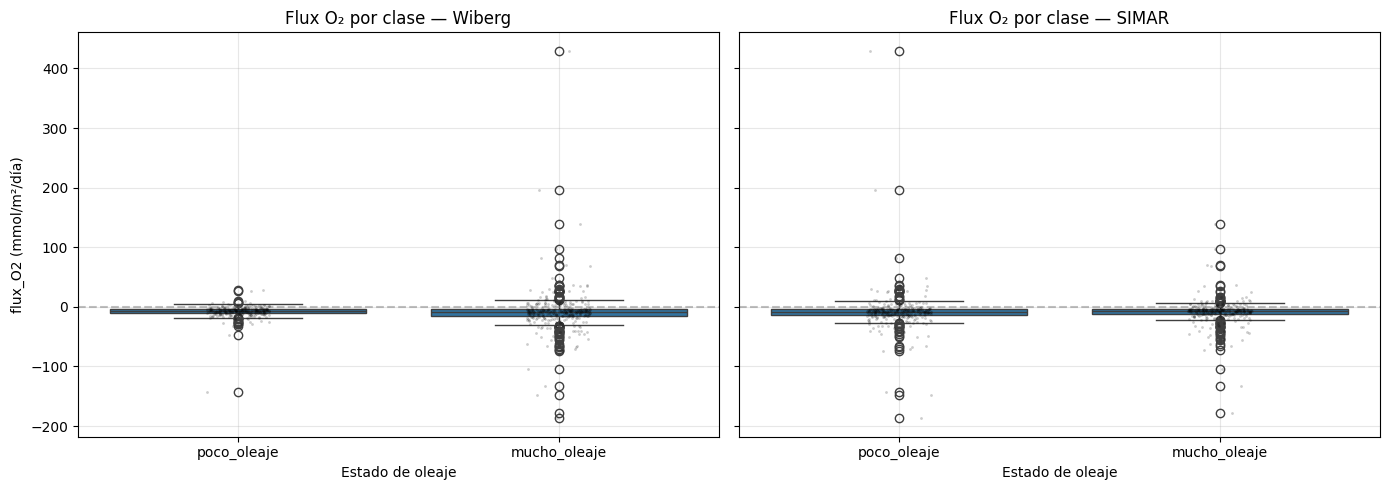

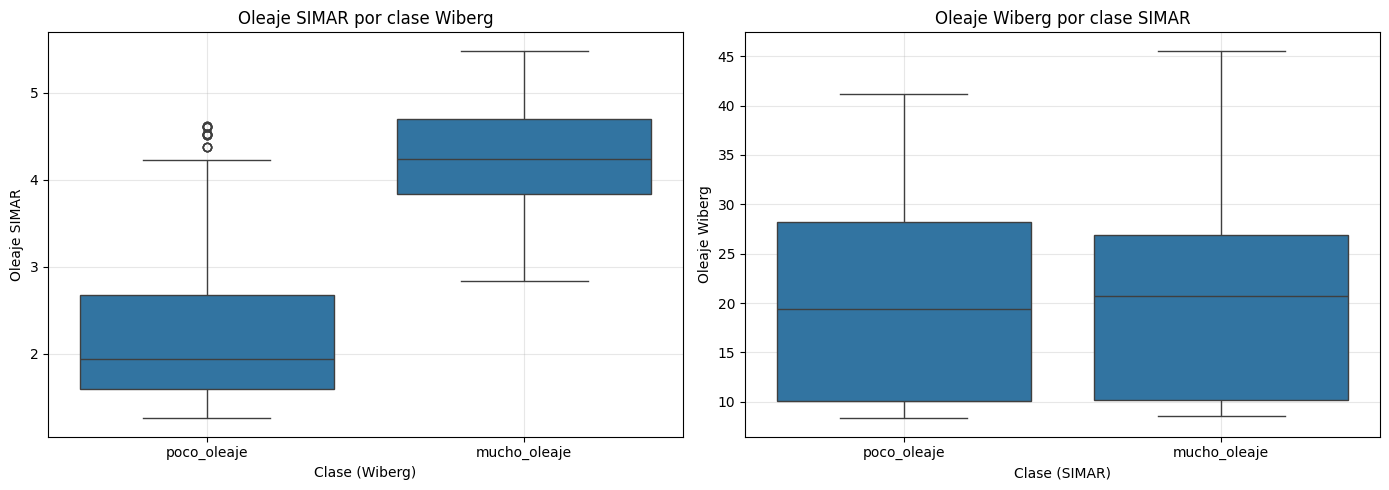

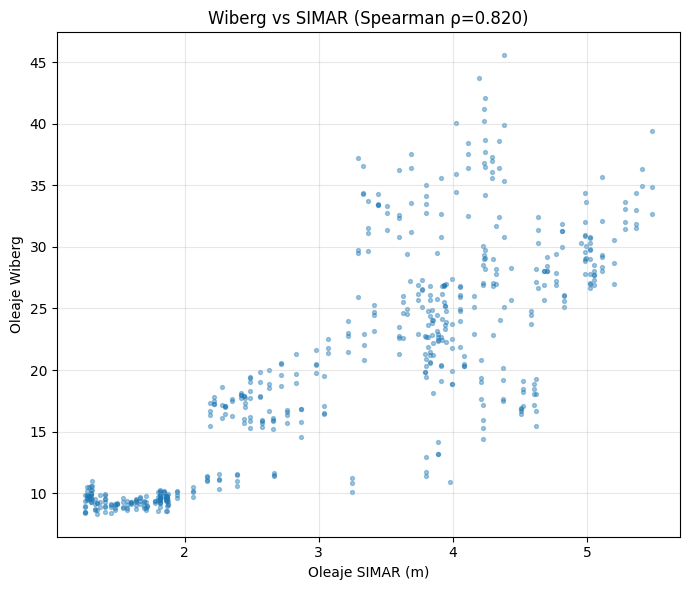

In [20]:
# ============================================================
# 6.1d FIGURAS COMPARACIÓN: boxplots flux + validación cruzada + scatter inter-fuente
# ============================================================

# Figura 1: Boxplots flux_O2 por estado (ambos escenarios lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, (nombre, col_clase) in enumerate(clase_cols.items()):
    col_nombre = f"{col_clase}_nombre"
    sns.boxplot(data=df, x=col_nombre, y="flux_O2", ax=axes[i])
    sns.stripplot(data=df, x=col_nombre, y="flux_O2", ax=axes[i],
                  color="black", alpha=0.2, size=2)
    axes[i].axhline(0, linestyle="--", color="gray", alpha=0.5)
    axes[i].set_title(f"Flux O₂ por clase — {nombre}")
    axes[i].set_xlabel("Estado de oleaje")
    axes[i].set_ylabel("flux_O2 (mmol/m²/día)" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figura 2: Validación cruzada (oleaje alternativo por clase)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if "oleaje_clase_Wiberg_nombre" in df.columns:
    sns.boxplot(data=df, x="oleaje_clase_Wiberg_nombre", y="Oleaje_SIMAR", ax=axes[0])
    axes[0].set_title("Oleaje SIMAR por clase Wiberg")
    axes[0].set_xlabel("Clase (Wiberg)")
    axes[0].set_ylabel("Oleaje SIMAR")
    axes[0].grid(True, alpha=0.3)
if "oleaje_clase_SIMAR_nombre" in df.columns:
    sns.boxplot(data=df, x="oleaje_clase_SIMAR_nombre", y="Oleaje", ax=axes[1])
    axes[1].set_title("Oleaje Wiberg por clase SIMAR")
    axes[1].set_xlabel("Clase (SIMAR)")
    axes[1].set_ylabel("Oleaje Wiberg")
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figura 3: Scatter Wiberg vs SIMAR
if "Oleaje" in df.columns and "Oleaje_SIMAR" in df.columns:
    aux = df[["Oleaje", "Oleaje_SIMAR"]].dropna()
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(aux["Oleaje_SIMAR"], aux["Oleaje"], s=8, alpha=0.4)
    ax.set_xlabel("Oleaje SIMAR (m)")
    ax.set_ylabel("Oleaje Wiberg")
    ax.set_title(f"Wiberg vs SIMAR (Spearman ρ={rho_inter:.3f})")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6.2 Contraste de hipótesis entre grupos
Mann-Whitney U para cada escenario. Post-hoc por pares si k > 2.

In [21]:
# ============================================================
# 6.2 MANN-WHITNEY U / KRUSKAL-WALLIS por escenario
# ============================================================
from itertools import combinations

for nombre, col_clase in clase_cols.items():
    grupos = df[[col_clase, "flux_O2"]].dropna()
    clases = sorted(grupos[col_clase].unique())
    n_clases = len(clases)
    muestras = [grupos.loc[grupos[col_clase] == c, "flux_O2"].values for c in clases]

    print(f"\n{'='*60}")
    print(f"CONTRASTE — {nombre} ({n_clases} clases)")
    print(f"{'='*60}")

    if n_clases == 2:
        stat, p = mannwhitneyu(muestras[0], muestras[1], alternative="two-sided")
        test_usado = "Mann-Whitney U"
        n1, n2 = len(muestras[0]), len(muestras[1])
        r_effect = 1 - (2 * stat) / (n1 * n2)
        print(f"  Test: {test_usado}")
        print(f"  U = {stat:.2f}, p = {p:.6f}")
        print(f"  Tamaño del efecto (rank-biserial r) = {r_effect:.4f}")
        print(f"  Mediana poco_oleaje: {np.median(muestras[0]):.4f}")
        print(f"  Mediana mucho_oleaje: {np.median(muestras[1]):.4f}")
        print(f"  Significativo: {p < ALPHA}")
    else:
        stat, p = kruskal(*muestras)
        test_usado = "Kruskal-Wallis"
        print(f"  Test: {test_usado}")
        print(f"  H = {stat:.4f}, p = {p:.6f}")
        print(f"  Significativo: {p < ALPHA}")

        # Post-hoc por pares si significativo
        if p < ALPHA:
            pares = list(combinations(clases, 2))
            n_pares = len(pares)
            resultados_posthoc = []
            for c1, c2 in pares:
                m1 = grupos.loc[grupos[col_clase] == c1, "flux_O2"].values
                m2 = grupos.loc[grupos[col_clase] == c2, "flux_O2"].values
                stat_par, p_par = mannwhitneyu(m1, m2, alternative="two-sided")
                resultados_posthoc.append({
                    "grupo_1": c1, "grupo_2": c2,
                    "U": round(stat_par, 2), "p": round(p_par, 6),
                })
            df_ph = pd.DataFrame(resultados_posthoc)
            df_ph["p_bonferroni"] = (df_ph["p"] * n_pares).clip(upper=1.0)
            df_ph["sig"] = df_ph["p_bonferroni"] < ALPHA
            display(df_ph)


CONTRASTE — Wiberg (2 clases)
  Test: Mann-Whitney U
  U = 62255.00, p = 0.000923
  Tamaño del efecto (rank-biserial r) = -0.1494
  Mediana poco_oleaje: -6.6602
  Mediana mucho_oleaje: -8.2186
  Significativo: True

CONTRASTE — SIMAR (2 clases)
  Test: Mann-Whitney U
  U = 49578.00, p = 0.047045
  Tamaño del efecto (rank-biserial r) = 0.0893
  Mediana poco_oleaje: -7.9643
  Mediana mucho_oleaje: -6.8161
  Significativo: True


### 6.3 Asociación entre spikes y estado de oleaje
Contraste de independencia Chi-cuadrado: ¿la presencia de spikes depende del estado de oleaje?

In [22]:
# ============================================================
# 6.3 CHI-CUADRADO: spikes vs estado de oleaje (por escenario)
# ============================================================

spike_col = None
for candidate in ["flag_outlier_window", "outlier_O2", "flag_outlier_global"]:
    if candidate in df.columns:
        spike_col = candidate
        break

if spike_col is not None:
    for nombre, col_clase in clase_cols.items():
        df_chi = df[[col_clase, spike_col]].dropna().copy()
        df_chi[spike_col] = df_chi[spike_col].astype(bool)

        tabla_contingencia = pd.crosstab(
            df_chi[col_clase],
            df_chi[spike_col],
            rownames=["estado_oleaje"],
            colnames=["spike"],
        )

        chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)

        print(f"\n=== Chi-cuadrado — {nombre} ===")
        display(tabla_contingencia)
        print(f"  χ² = {chi2:.4f}, p = {p_chi:.4f}, dof = {dof}")
        if p_chi < ALPHA:
            print(f"  → Dependencia significativa entre spikes y estado de oleaje")
        else:
            print(f"  → No hay evidencia de dependencia")
else:
    print("No se encontró columna de spikes en el dataset.")


=== Chi-cuadrado — Wiberg ===


spike,False,True
estado_oleaje,,
0,179,127
1,159,195


  χ² = 11.5794, p = 0.0007, dof = 1
  → Dependencia significativa entre spikes y estado de oleaje

=== Chi-cuadrado — SIMAR ===


spike,False,True
estado_oleaje,,
0,180,146
1,158,176


  χ² = 3.8201, p = 0.0506, dof = 1
  → No hay evidencia de dependencia


### 6.4 Correlaciones de Spearman
Correlación no paramétrica entre flux_O2 y todas las variables hidrodinámicas.

In [23]:
# ============================================================
# 6.4 CORRELACIONES DE SPEARMAN: flux_O2 vs variables hidrodinámicas
# ============================================================

resultados_spear = []

for etiqueta, col_real in vars_oleaje.items():
    aux = df[["flux_O2", col_real]].dropna()
    if len(aux) < 5:
        continue
    rho, p_sp = spearmanr(aux["flux_O2"], aux[col_real])
    resultados_spear.append({
        "Variable": etiqueta,
        "Columna": col_real,
        "Spearman ρ": round(rho, 4),
        "p-value": round(p_sp, 6),
        "Significativo": p_sp < ALPHA,
        "n": len(aux),
    })

df_spearman = pd.DataFrame(resultados_spear)
print("Correlaciones Spearman: flux_O2 vs variables de oleaje")
display(df_spearman)

Correlaciones Spearman: flux_O2 vs variables de oleaje


,Variable,Columna,Spearman ρ,p-value,Significativo,n
0,Oleaje,Oleaje,-0.1665,0.000087,True,550
1,Mod_orbital,Mod_orbital,-0.1774,0.000005,True,660
2,STD_orbital,STD_orbital,-0.1723,0.000009,True,660
3,Oleaje_SIMAR,Oleaje_SIMAR,-0.1694,0.000012,True,660
4,mean_pres,pres__mean,0.0305,0.433604,False,660
5,std_pres,pres__standard_deviation,-0.1628,0.000026,True,660


### 6.5 Gráficos de soporte
- Scatterplots flux_O2 vs oleaje (ambas fuentes)
- Serie temporal coloreada por clase
- Barras: % spikes por estado de oleaje

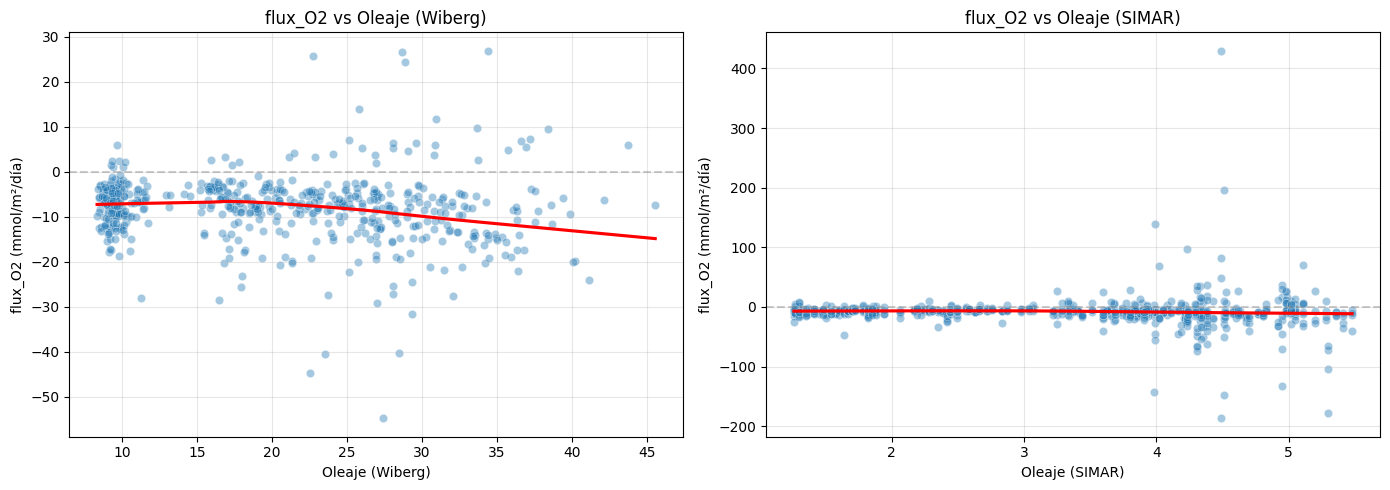

In [24]:
# ============================================================
# 6.5a SCATTERPLOTS: flux_O2 vs oleaje (ambas fuentes con LOWESS)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, titulo) in zip(axes, [("Oleaje", "Wiberg"), ("Oleaje_SIMAR", "SIMAR")]):
    if col not in df.columns:
        continue
    aux = df[[col, "flux_O2"]].dropna()
    sns.scatterplot(data=aux, x=col, y="flux_O2", alpha=0.4, ax=ax)
    sns.regplot(data=aux, x=col, y="flux_O2", scatter=False,
                lowess=True, color="red", ax=ax)
    ax.axhline(0, linestyle="--", color="gray", alpha=0.4)
    ax.set_title(f"flux_O2 vs Oleaje ({titulo})")
    ax.set_xlabel(f"Oleaje ({titulo})")
    ax.set_ylabel("flux_O2 (mmol/m²/día)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

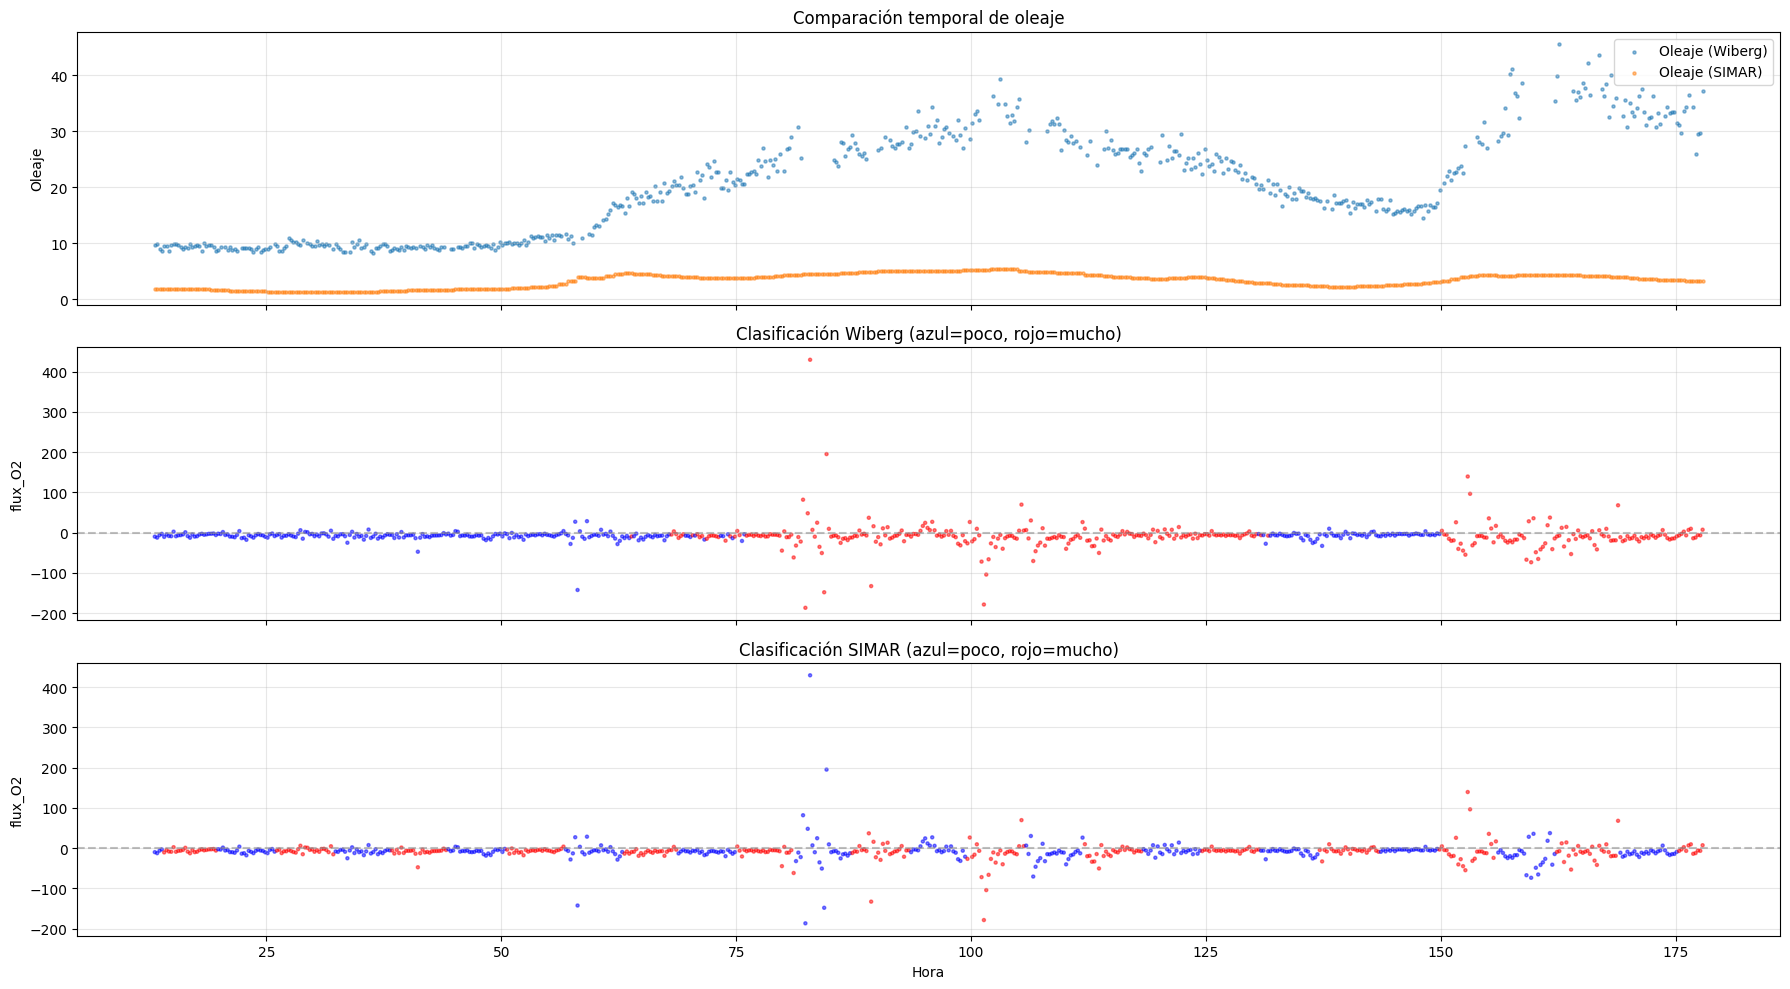

In [25]:
# ============================================================
# 6.5b SERIE TEMPORAL: oleaje + flux coloreado por clase
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Panel 1: Oleaje ambas fuentes
ax = axes[0]
ax.scatter(df["hour"], df["Oleaje"], s=5, alpha=0.5, label="Oleaje (Wiberg)")
ax.scatter(df["hour"], df["Oleaje_SIMAR"], s=5, alpha=0.5, label="Oleaje (SIMAR)")
ax.set_ylabel("Oleaje")
ax.set_title("Comparación temporal de oleaje")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Flux coloreado por clase Wiberg
ax = axes[1]
if "oleaje_clase_Wiberg" in df.columns:
    colors = df["oleaje_clase_Wiberg"].map({0: "blue", 1: "red"})
    ax.scatter(df["hour"], df["flux_O2"], c=colors, s=5, alpha=0.5)
    ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_ylabel("flux_O2")
    ax.set_title("Clasificación Wiberg (azul=poco, rojo=mucho)")
    ax.grid(True, alpha=0.3)

# Panel 3: Flux coloreado por clase SIMAR
ax = axes[2]
if "oleaje_clase_SIMAR" in df.columns:
    colors = df["oleaje_clase_SIMAR"].map({0: "blue", 1: "red"})
    ax.scatter(df["hour"], df["flux_O2"], c=colors, s=5, alpha=0.5)
    ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlabel("Hora")
    ax.set_ylabel("flux_O2")
    ax.set_title("Clasificación SIMAR (azul=poco, rojo=mucho)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()